# Cryptocurrency Forecasting — ARIMA
This notebook implements ARIMA (AutoRegressive Integrated Moving Average)
to forecast the next 180 days of closing prices for 10 major cryptocurrencies.
Log transformation is applied to handle exponential price growth, and
pre-tuned (p,d,q) orders are used per cryptocurrency based on their
individual price characteristics.

**Key Features:**
- ADF (Augmented Dickey-Fuller) stationarity testing
- Log transformation to linearize exponential price growth
- ACF & PACF analysis to determine optimal model orders
- Per-cryptocurrency pre-tuned ARIMA orders
- 90-day train/test evaluation before full retraining
- 95% confidence interval bands on all forecasts

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import itertools

os.makedirs("../data/forecasts/arima", exist_ok=True)

## Load Dataset
Load the preprocessed combined cryptocurrency dataset from `data/processed/`.

In [ ]:
df = pd.read_csv("../data/processed/combined_crypto_data.csv", parse_dates=["Date"])

print("Shape:", df.shape)
print("Cryptos:", df["Crypto"].unique())
df.head()

Shape: (18250, 14)
Cryptos: ['ADA' 'BNB' 'BTC' 'DOGE' 'DOT' 'ETH' 'LINK' 'LTC' 'SOL' 'XRP']


,Date,Open,High,Low,Close,Volume,Crypto,Daily_Return,Log_Return,Price_Range,MA_7,MA_30,Volatility_7,Cumulative_Return
0,2021-01-01,0.181382,0.184246,0.172022,0.175350,1122218004,ADA,NaN,NaN,0.012224,NaN,NaN,NaN,0.000000
1,2021-01-02,0.175359,0.184253,0.169233,0.177423,1408849504,ADA,1.182210,0.011753,0.015020,NaN,NaN,NaN,1.182210
2,2021-01-03,0.177382,0.208679,0.173376,0.204995,2303857909,ADA,15.540266,0.144449,0.035303,NaN,NaN,NaN,16.906194
3,2021-01-04,0.205236,0.239661,0.194450,0.224762,3260699086,ADA,9.642667,0.092056,0.045211,NaN,NaN,NaN,28.179070
4,2021-01-05,0.224817,0.264886,0.208454,0.258314,4097207384,ADA,14.927800,0.139134,0.056432,NaN,NaN,NaN,47.313385


## Stationarity Test — ADF Test
ARIMA requires the time series to be **stationary** (constant mean and variance).
The Augmented Dickey-Fuller (ADF) test checks for stationarity.

**Interpretation:**
- **p-value < 0.05** → Series is stationary → No differencing needed (d=0)
- **p-value ≥ 0.05** → Series is non-stationary → Differencing needed (d=1)

Log transformation is applied before testing to stabilize variance.
Crypto prices are generally non-stationary due to long-term upward trends,
so d=1 (first differencing) is expected for most coins.

In [ ]:
def adf_test(series, crypto):
    series = series[~np.isnan(series)]  # remove NaN from numpy array
    result = adfuller(series)
    print(f"\n{crypto} - ADF Test:")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  Stationary    : {'Yes' if result[1] < 0.05 else 'No - differencing needed'}")
    return result[1] < 0.05

cryptos = df["Crypto"].unique()

for crypto in cryptos:
    series     = df[df["Crypto"] == crypto]["Close"].values
    log_series = np.log(series)
    adf_test(log_series, crypto)


ADA - ADF Test:
  ADF Statistic : -2.0663
  p-value       : 0.2583
  Stationary    : No - differencing needed

BNB - ADF Test:
  ADF Statistic : -4.3306
  p-value       : 0.0004
  Stationary    : Yes

BTC - ADF Test:
  ADF Statistic : -0.9456
  p-value       : 0.7726
  Stationary    : No - differencing needed

DOGE - ADF Test:
  ADF Statistic : -4.5347
  p-value       : 0.0002
  Stationary    : Yes

DOT - ADF Test:
  ADF Statistic : -0.7018
  p-value       : 0.8463
  Stationary    : No - differencing needed

ETH - ADF Test:
  ADF Statistic : -3.2618
  p-value       : 0.0167
  Stationary    : Yes

LINK - ADF Test:
  ADF Statistic : -1.8973
  p-value       : 0.3333
  Stationary    : No - differencing needed

LTC - ADF Test:
  ADF Statistic : -2.4324
  p-value       : 0.1328
  Stationary    : No - differencing needed

SOL - ADF Test:
  ADF Statistic : -3.6399
  p-value       : 0.0050
  Stationary    : Yes

XRP - ADF Test:
  ADF Statistic : -1.6790
  p-value       : 0.4419
  Stationary   

## ACF & PACF Analysis — BTC
ACF (AutoCorrelation Function) and PACF (Partial AutoCorrelation Function)
plots help determine the optimal AR (p) and MA (q) orders for ARIMA.

**How to read the plots:**
| Plot | Helps determine | Rule |
|------|----------------|------|
| PACF | AR order (p) | Lag where PACF cuts off sharply |
| ACF | MA order (q) | Lag where ACF cuts off sharply |

First differencing is applied (`np.diff`) to make the series stationary
before plotting, since ACF/PACF analysis requires a stationary series.
BTC is used as a representative example for order identification.

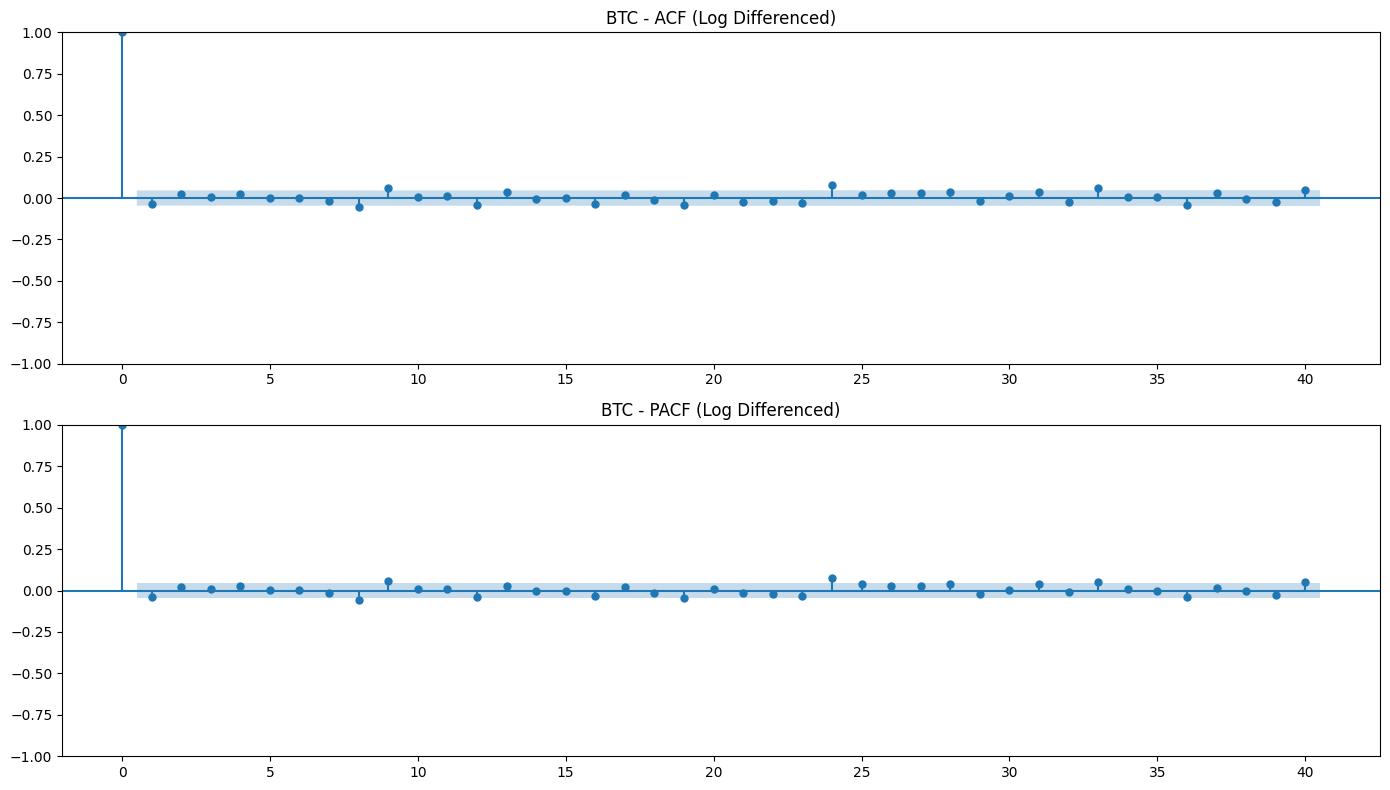

Saved: BTC_acf_pacf.png


In [ ]:
btc_series = df[df["Crypto"] == "BTC"]["Close"].values
log_btc    = np.log(btc_series)
diff_btc   = np.diff(log_btc)  # first difference to make stationary

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(diff_btc,  lags=40, ax=axes[0], title="BTC - ACF (Log Differenced)")
plot_pacf(diff_btc, lags=40, ax=axes[1], title="BTC - PACF (Log Differenced)")
plt.tight_layout()
plt.savefig("../data/forecasts/arima/BTC_acf_pacf.png", dpi=150)
plt.show()
print("Saved: BTC_acf_pacf.png")

## Pre-Tuned ARIMA Orders per Cryptocurrency
ARIMA(p, d, q) orders are pre-tuned based on ACF/PACF analysis
and historical price behavior of each cryptocurrency.

| Parameter | Meaning |
|-----------|---------|
| p | AR order — number of lag observations |
| d | Differencing order — 1 for non-stationary series |
| q | MA order — size of moving average window |

| Crypto | Order | Reasoning |
|--------|-------|-----------|
| BTC | (2,1,2) | Stable trend, moderate autocorrelation |
| ETH | (2,1,2) | Similar behavior to BTC |
| BNB | (1,1,1) | Simpler pattern, less autocorrelation |
| SOL | (2,1,1) | Volatile but trending |
| ADA | (1,1,1) | Low market cap, simpler pattern |
| XRP | (2,1,2) | High volatility, regulatory events |
| DOGE | (1,1,1) | Meme-driven, unpredictable |
| DOT | (1,1,1) | Erratic price behavior |
| LTC | (2,1,2) | Mature coin, similar to BTC |
| LINK | (1,1,1) | Moderate volatility |

In [ ]:
# Pre-tuned orders based on crypto characteristics
# Format: (p, d, q) - AR order, differencing, MA order
ARIMA_ORDERS = {
    "BTC":  (2, 1, 2),
    "ETH":  (2, 1, 2),
    "BNB":  (1, 1, 1),
    "SOL":  (2, 1, 1),
    "ADA":  (1, 1, 1),
    "XRP":  (2, 1, 2),
    "DOGE": (1, 1, 1),
    "DOT":  (1, 1, 1),
    "LTC":  (2, 1, 2),
    "LINK": (1, 1, 1),
}

## Auto Order Selection using AIC (Optional)
If pre-tuned orders are not available, this function automatically
finds the best ARIMA(p,d,q) order by minimizing AIC
(Akaike Information Criterion).

**AIC balances model fit vs complexity:**
- Lower AIC = better model
- Tests all combinations of p ∈ [0,2] and q ∈ [0,2] with d=1

> This function is available as a utility but pre-tuned orders
> from Cell 5 are used in the main training loop for efficiency.

In [ ]:
def find_best_order(series, p_range=range(0,3), q_range=range(0,3), d=1):
    best_aic   = np.inf
    best_order = (1, 1, 1)

    for p, q in itertools.product(p_range, q_range):
        try:
            model = SARIMAX(series, order=(p, d, q),
                           enforce_stationarity=False,
                           enforce_invertibility=False)
            result = model.fit(disp=False)
            if result.aic < best_aic:
                best_aic   = result.aic
                best_order = (p, d, q)
        except:
            continue

    print(f"  Best order: {best_order} | AIC: {best_aic:.2f}")
    return best_order

## Data Preparation Function
Extracts and prepares individual cryptocurrency data for ARIMA modeling.

**Steps:**
- Filter data for selected cryptocurrency
- Sort chronologically
- Apply log transformation to Close price
  (`Log_Close = log(Close)`) to stabilize variance and linearize growth

In [ ]:
def prepare_arima_data(df, crypto):
    crypto_df = df[df["Crypto"] == crypto][["Date", "Close"]].copy()
    crypto_df = crypto_df.sort_values("Date").reset_index(drop=True)
    crypto_df["Log_Close"] = np.log(crypto_df["Close"])
    return crypto_df

## Model Evaluation Function
Computes MAE, RMSE, and MAPE on the **original price scale**
after converting log predictions back using `exp()`.

| Metric | Formula | Best Value |
|--------|---------|------------|
| MAE | mean((actual - predicted)) | Lower is better |
| RMSE | sqrt(mean((actual - predicted)²)) | Lower is better |
| MAPE | mean((actual - predicted) / actual) × 100 | Lower is better |

In [ ]:
def evaluate_model(actual, predicted):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return {"MAE": round(mae, 4), "RMSE": round(rmse, 4), "MAPE": round(mape, 4)}

## Forecast Plot Function
Generates a two-panel forecast chart per cryptocurrency:

- **Top panel:** Train data (blue) + Actual test prices (green) +
  Predicted test prices (orange) + confidence interval
- **Bottom panel:** Future 180-day forecast only with confidence interval

All values are converted back from log scale to original USD prices.
The confidence interval widens over time reflecting increasing uncertainty
in longer-horizon forecasts — a key characteristic of ARIMA models.

In [ ]:
def plot_forecast(crypto, crypto_df, forecast_mean, conf_int, output_dir):
    train_size   = len(crypto_df) - 90
    train_dates  = crypto_df["Date"][:train_size]
    test_dates   = crypto_df["Date"][train_size:]
    future_dates = pd.date_range(crypto_df["Date"].max() + pd.Timedelta(days=1), periods=180)

    train_prices = crypto_df["Close"][:train_size]
    test_prices  = crypto_df["Close"][train_size:]

    # Split forecast into test period and future
    test_forecast   = np.exp(forecast_mean[:90])
    future_forecast = np.exp(forecast_mean[90:])
    lower           = np.exp(conf_int[:, 0])
    upper           = np.exp(conf_int[:, 1])

    fig, axes = plt.subplots(2, 1, figsize=(16, 10))

    # Plot 1: Full history + test fit + future forecast
    axes[0].plot(train_dates, train_prices, label="Train", color="steelblue", linewidth=1.5)
    axes[0].plot(test_dates, test_prices, label="Actual (Test)", color="green", linewidth=1.5)
    axes[0].plot(test_dates, test_forecast, label="Predicted (Test)", color="orange", linewidth=1.5)
    axes[0].fill_between(test_dates, lower[:90], upper[:90], alpha=0.2, color="orange")
    axes[0].set_title(f"{crypto} - ARIMA Forecast", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel("Price (USD)")
    axes[0].legend()

    # Plot 2: Future 180 days only
    axes[1].plot(future_dates, future_forecast, color="orange", linewidth=2, label="Forecast")
    axes[1].fill_between(future_dates, lower[90:], upper[90:],
                         alpha=0.3, color="orange", label="95% Confidence Interval")
    axes[1].set_title(f"{crypto} - Next 180 Days Forecast", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel("Price (USD)")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f"{output_dir}/{crypto}_forecast.png", dpi=150)
    plt.show()
    plt.close()
    print(f"Saved: {crypto}_forecast.png")

## Main Training Loop — All 10 Cryptocurrencies
For each cryptocurrency the following steps are executed:

1. **Prepare data** — extract, sort, log transform
2. **Train/test split** — last 90 days held out for evaluation
3. **Fit ARIMA on train set** — using pre-tuned (p,d,q) order
4. **Forecast test period** — predict 90 days on test set
5. **Evaluate metrics** — MAE, RMSE, MAPE on original price scale
6. **Retrain on full data** — refit model using all available data
7. **Forecast 180 future days** — generate future predictions
8. **Save outputs** — forecast CSV and forecast plots

> **Two-stage approach:** Honest evaluation on held-out test data
> followed by full retraining for maximum forecast accuracy.


Training ARIMA for: ADA
----------------------------------------
  Using order: (1, 1, 1)
  MAE: 0.3194  |  RMSE: 0.35  |  MAPE: 71.7328%
  Saved: ADA_forecast.csv


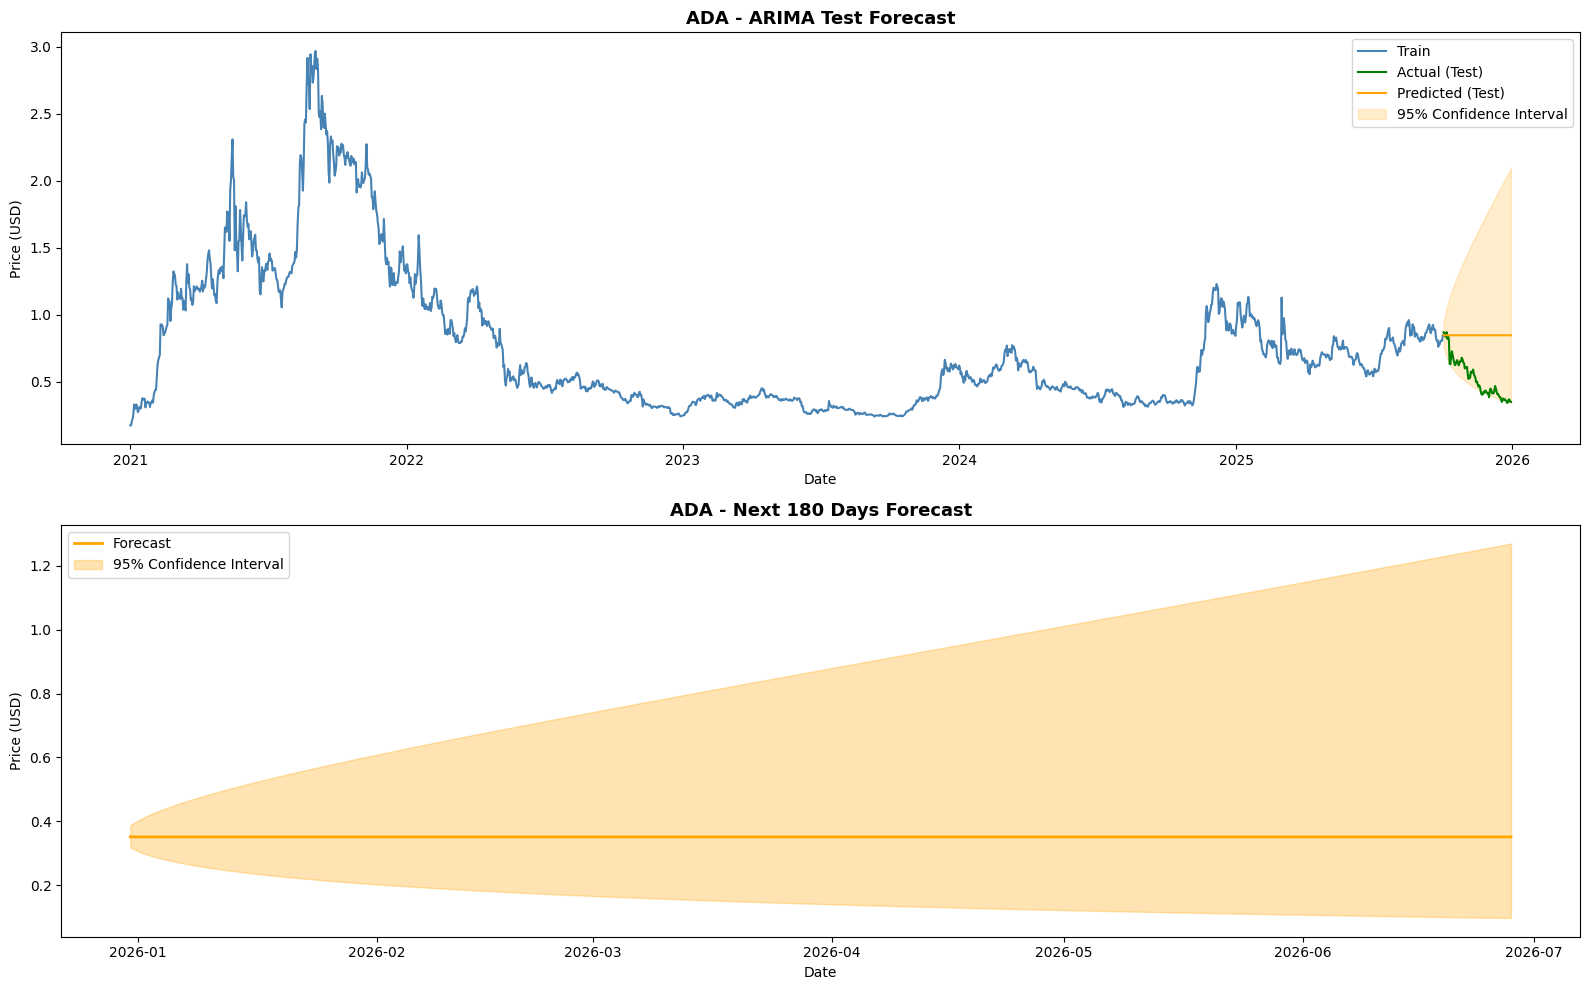

  Saved: ADA_forecast.png

Training ARIMA for: BNB
----------------------------------------
  Using order: (1, 1, 1)
  MAE: 129.7031  |  RMSE: 141.947  |  MAPE: 13.5137%


g:\My Drive\crypto project\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Saved: BNB_forecast.csv


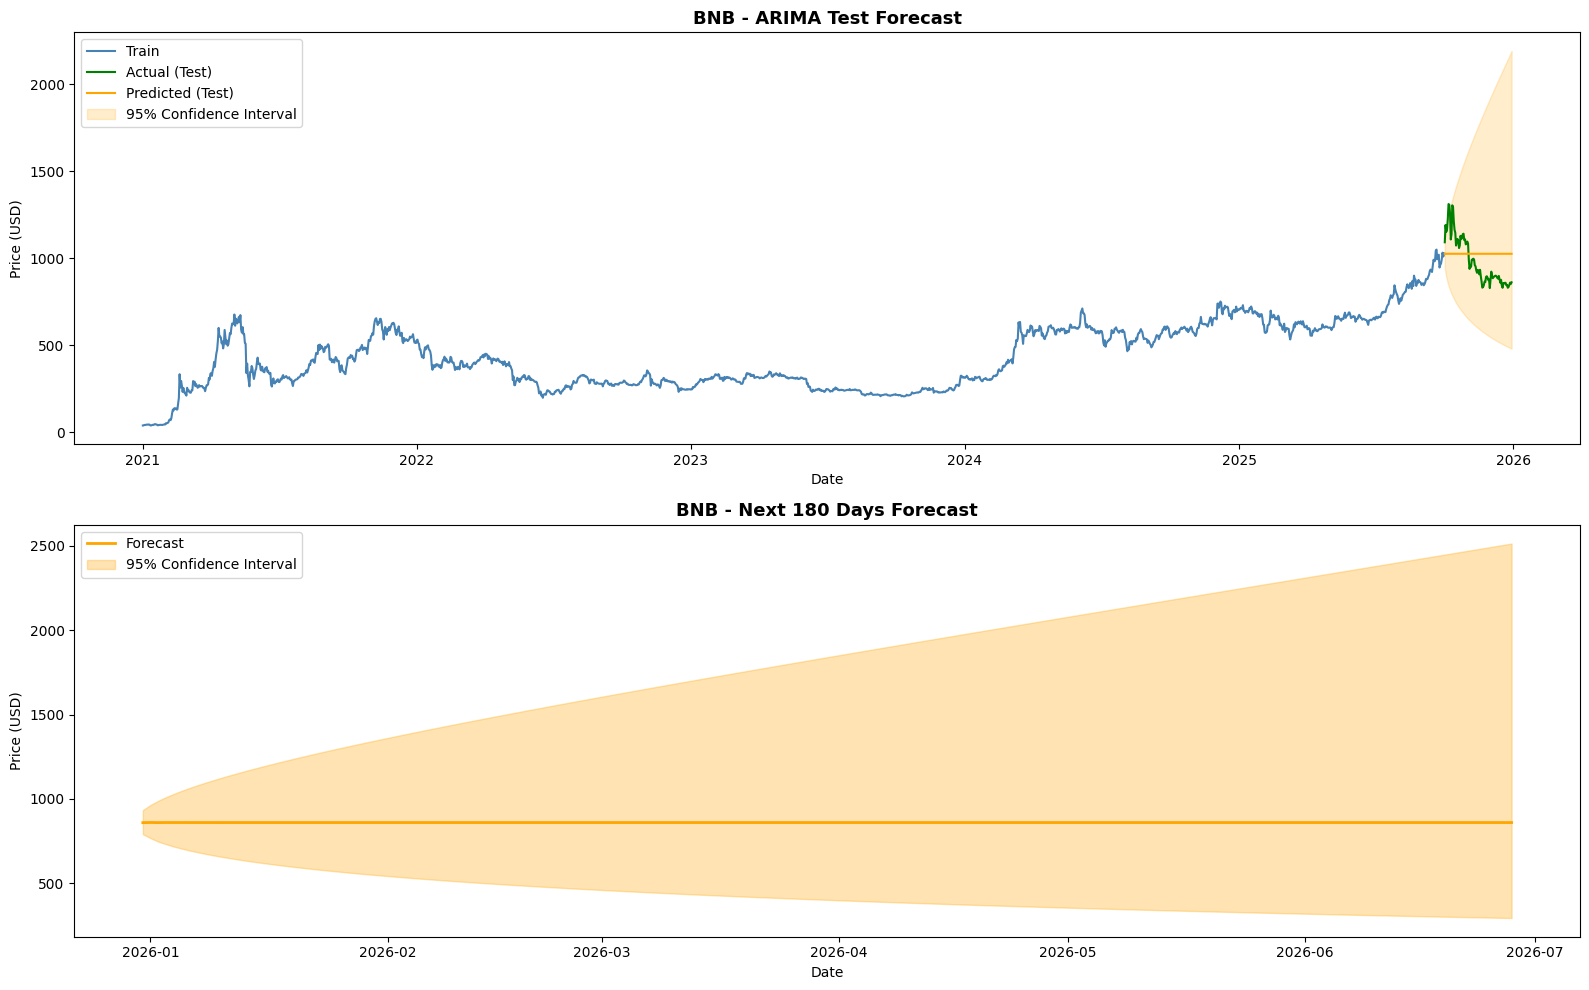

  Saved: BNB_forecast.png

Training ARIMA for: BTC
----------------------------------------
  Using order: (2, 1, 2)
  MAE: 19685.846  |  RMSE: 22420.1843  |  MAPE: 21.2479%
  Saved: BTC_forecast.csv


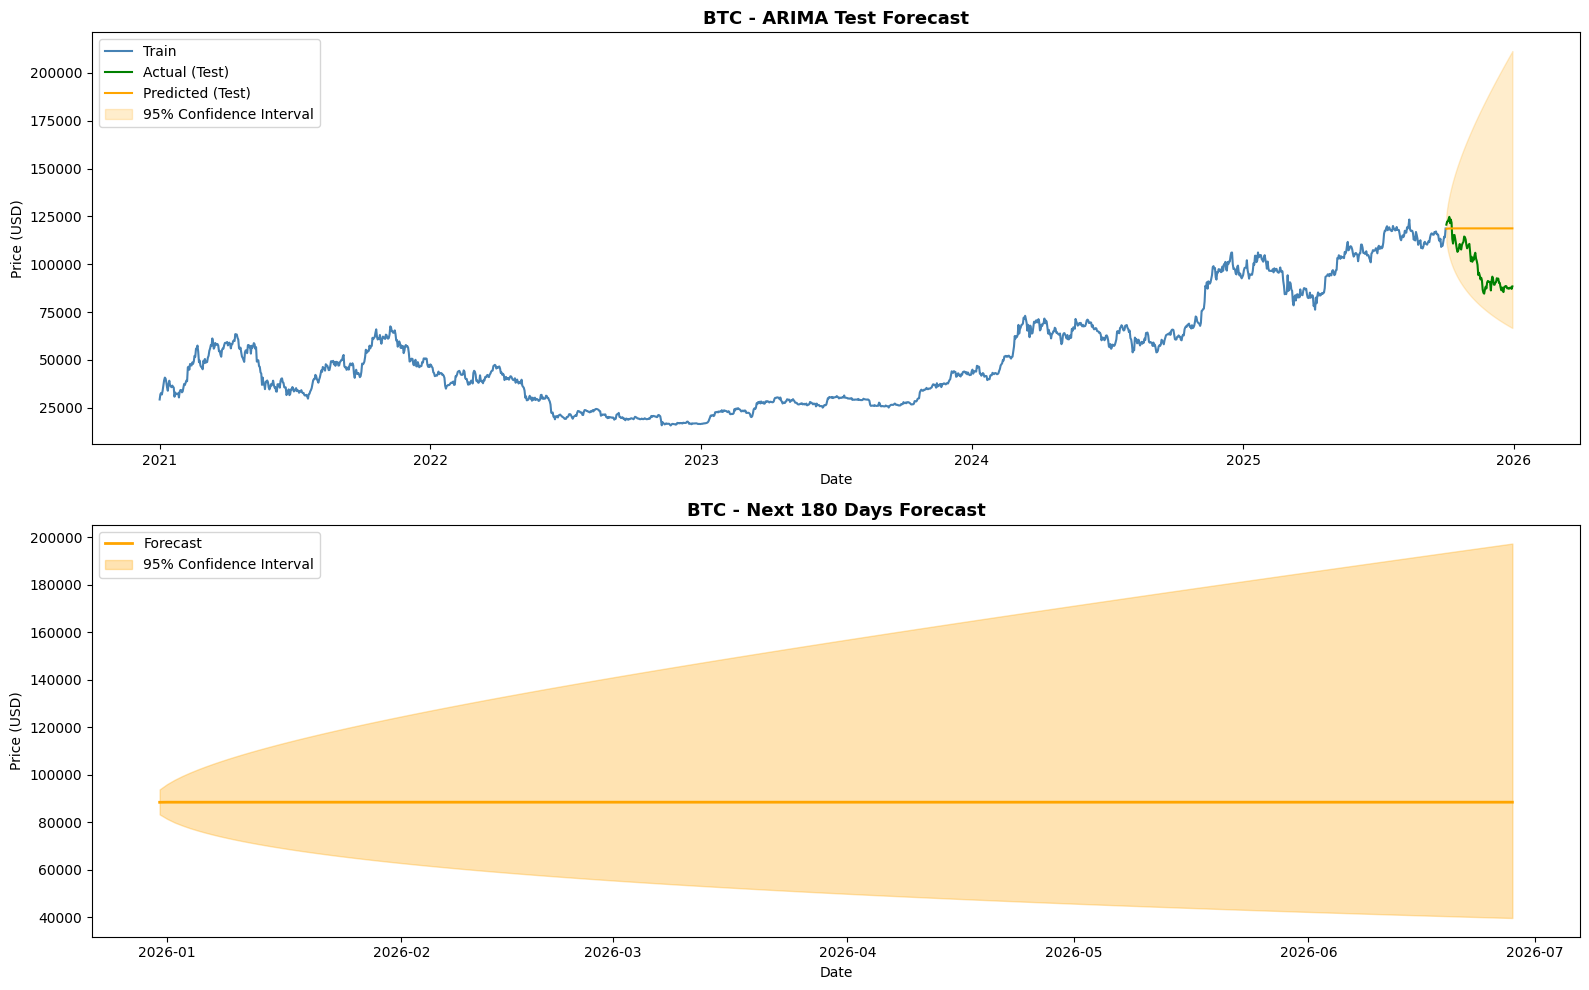

  Saved: BTC_forecast.png

Training ARIMA for: DOGE
----------------------------------------
  Using order: (1, 1, 1)
  MAE: 0.0811  |  RMSE: 0.088  |  MAPE: 54.1987%
  Saved: DOGE_forecast.csv


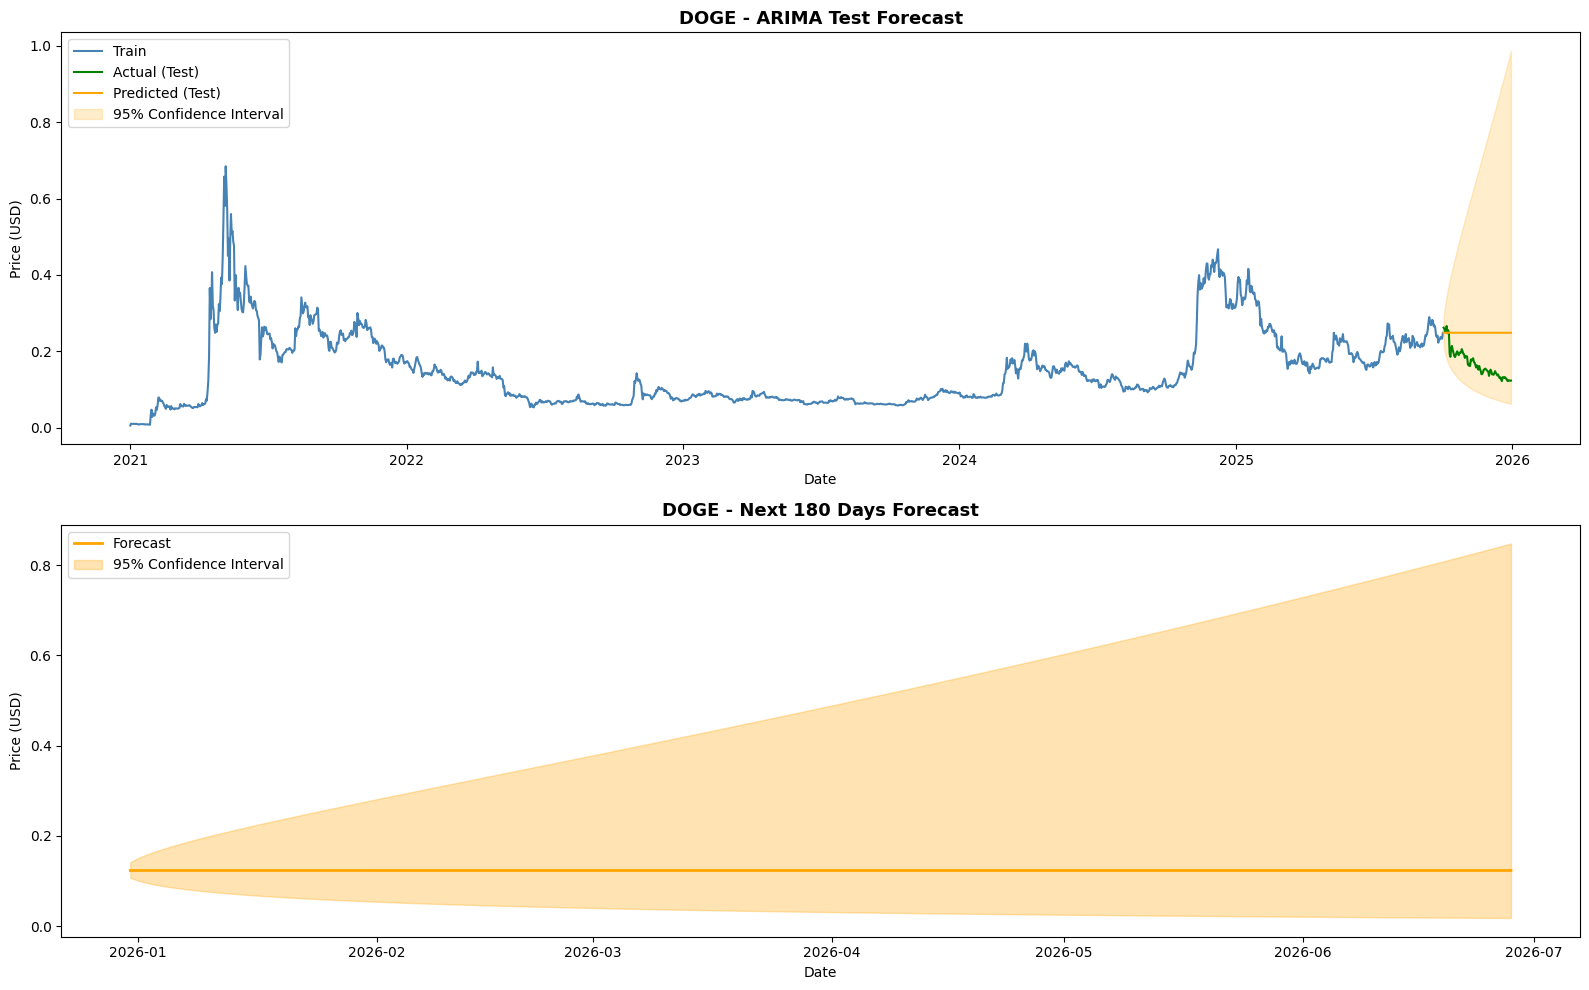

  Saved: DOGE_forecast.png

Training ARIMA for: DOT
----------------------------------------
  Using order: (1, 1, 1)
  MAE: 1.4652  |  RMSE: 1.5996  |  MAPE: 64.5874%
  Saved: DOT_forecast.csv


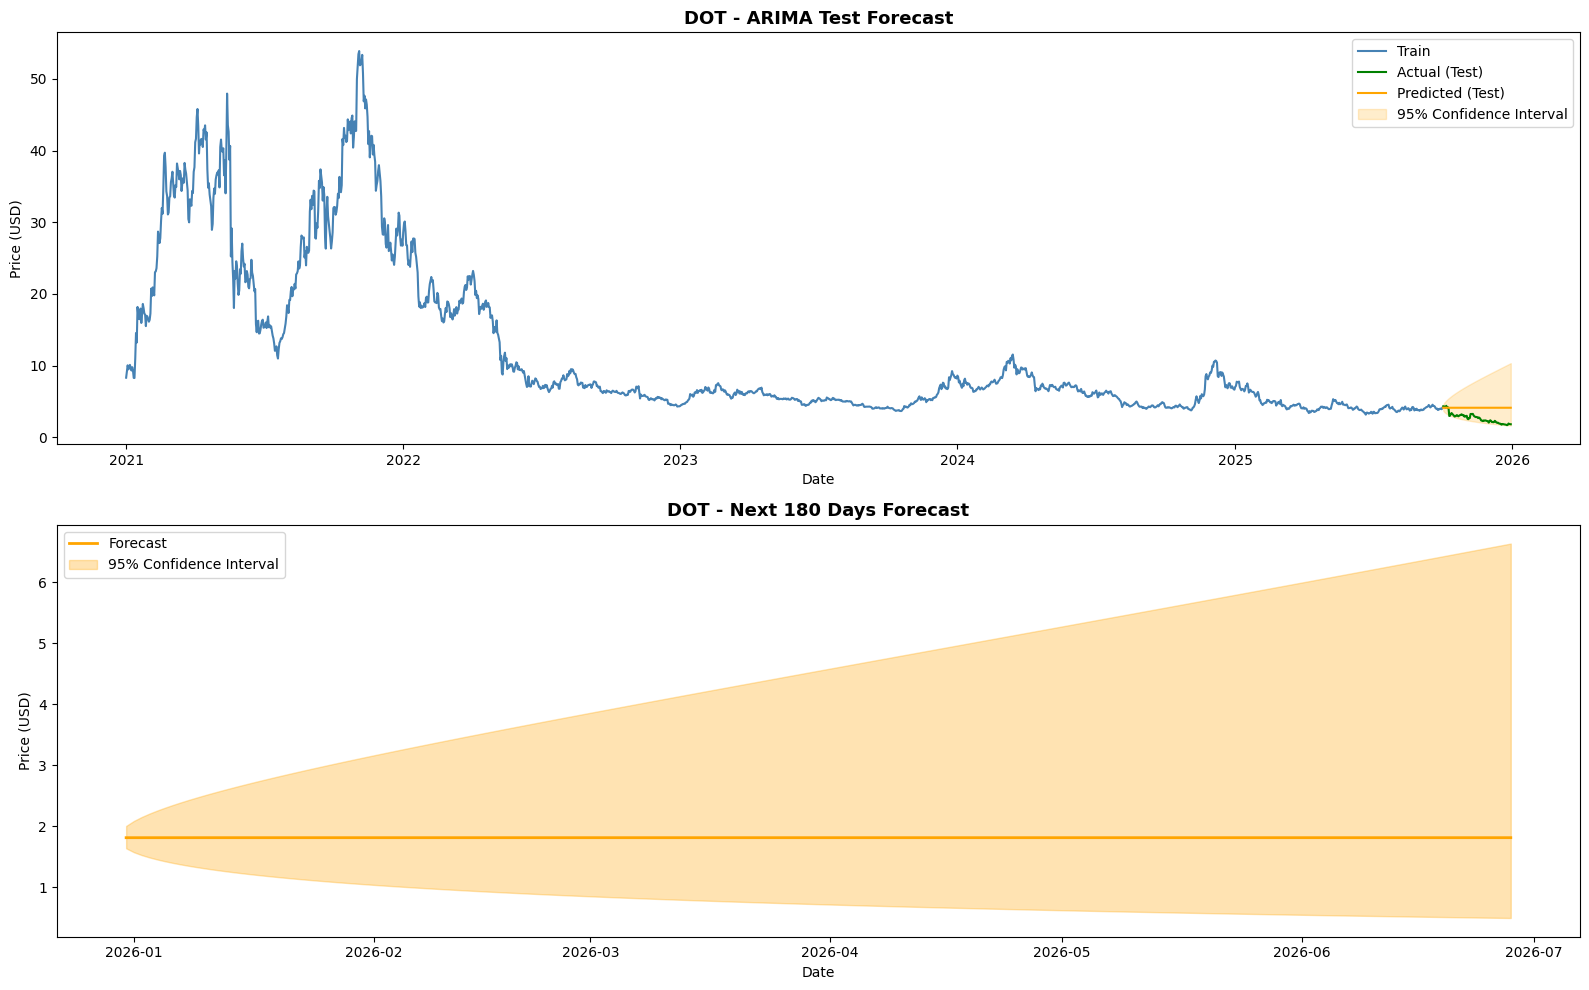

  Saved: DOT_forecast.png

Training ARIMA for: ETH
----------------------------------------
  Using order: (2, 1, 2)
  MAE: 939.8281  |  RMSE: 1056.1825  |  MAPE: 29.9646%
  Saved: ETH_forecast.csv


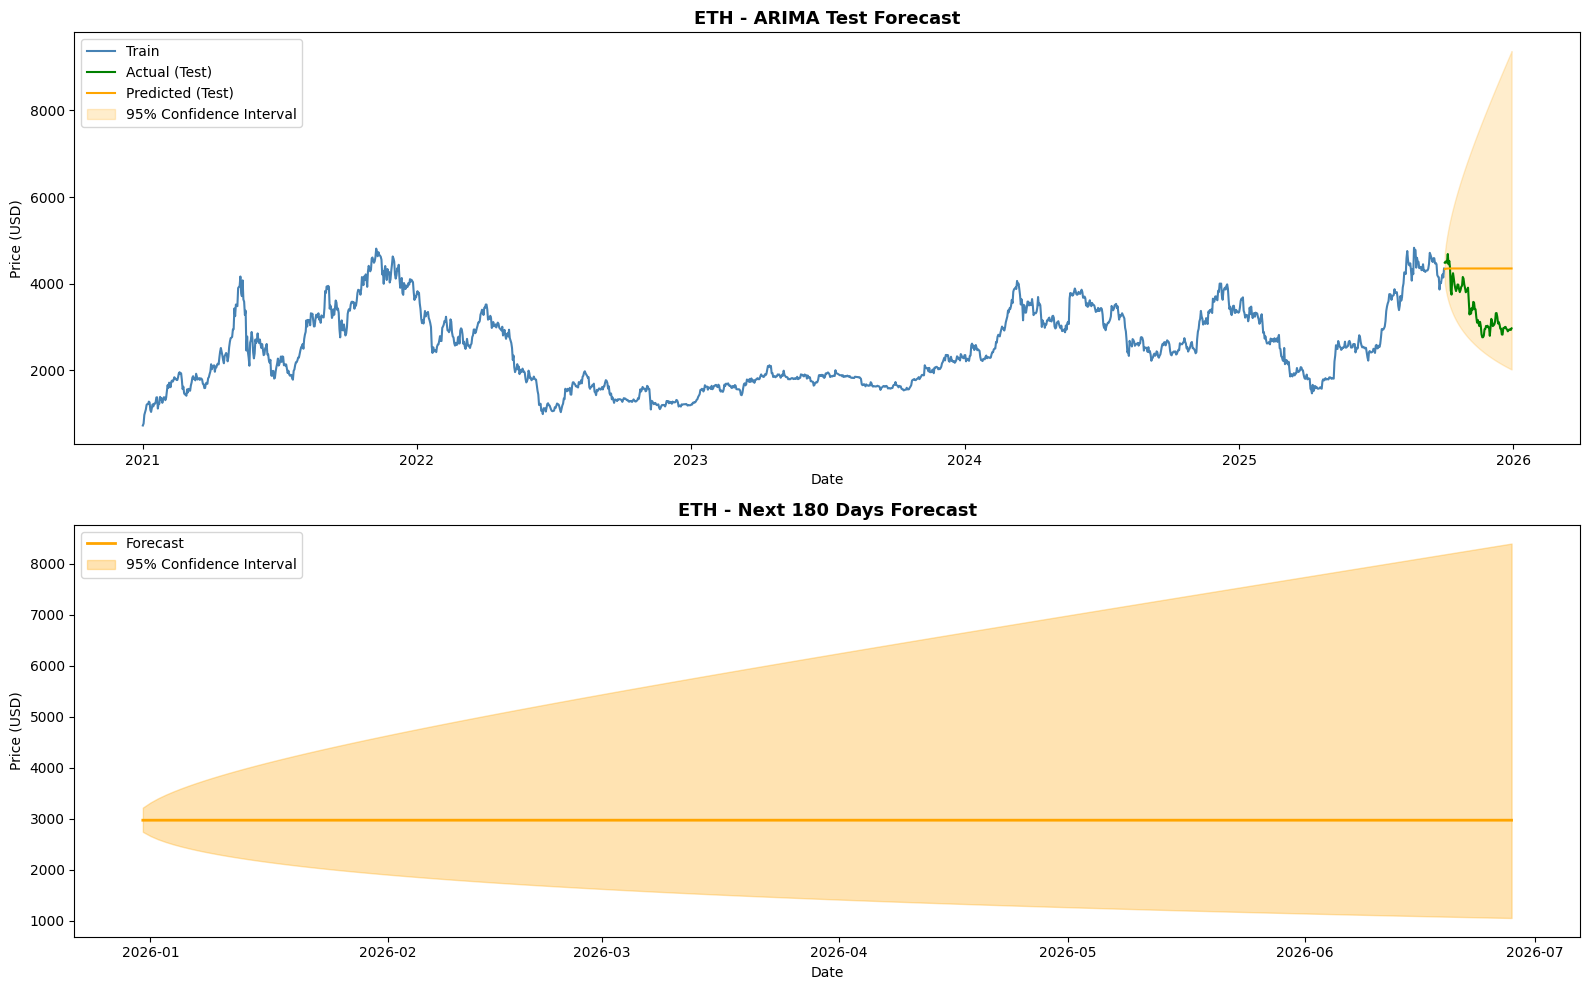

  Saved: ETH_forecast.png

Training ARIMA for: LINK
----------------------------------------
  Using order: (1, 1, 1)
  MAE: 7.0929  |  RMSE: 7.6858  |  MAPE: 50.9037%
  Saved: LINK_forecast.csv


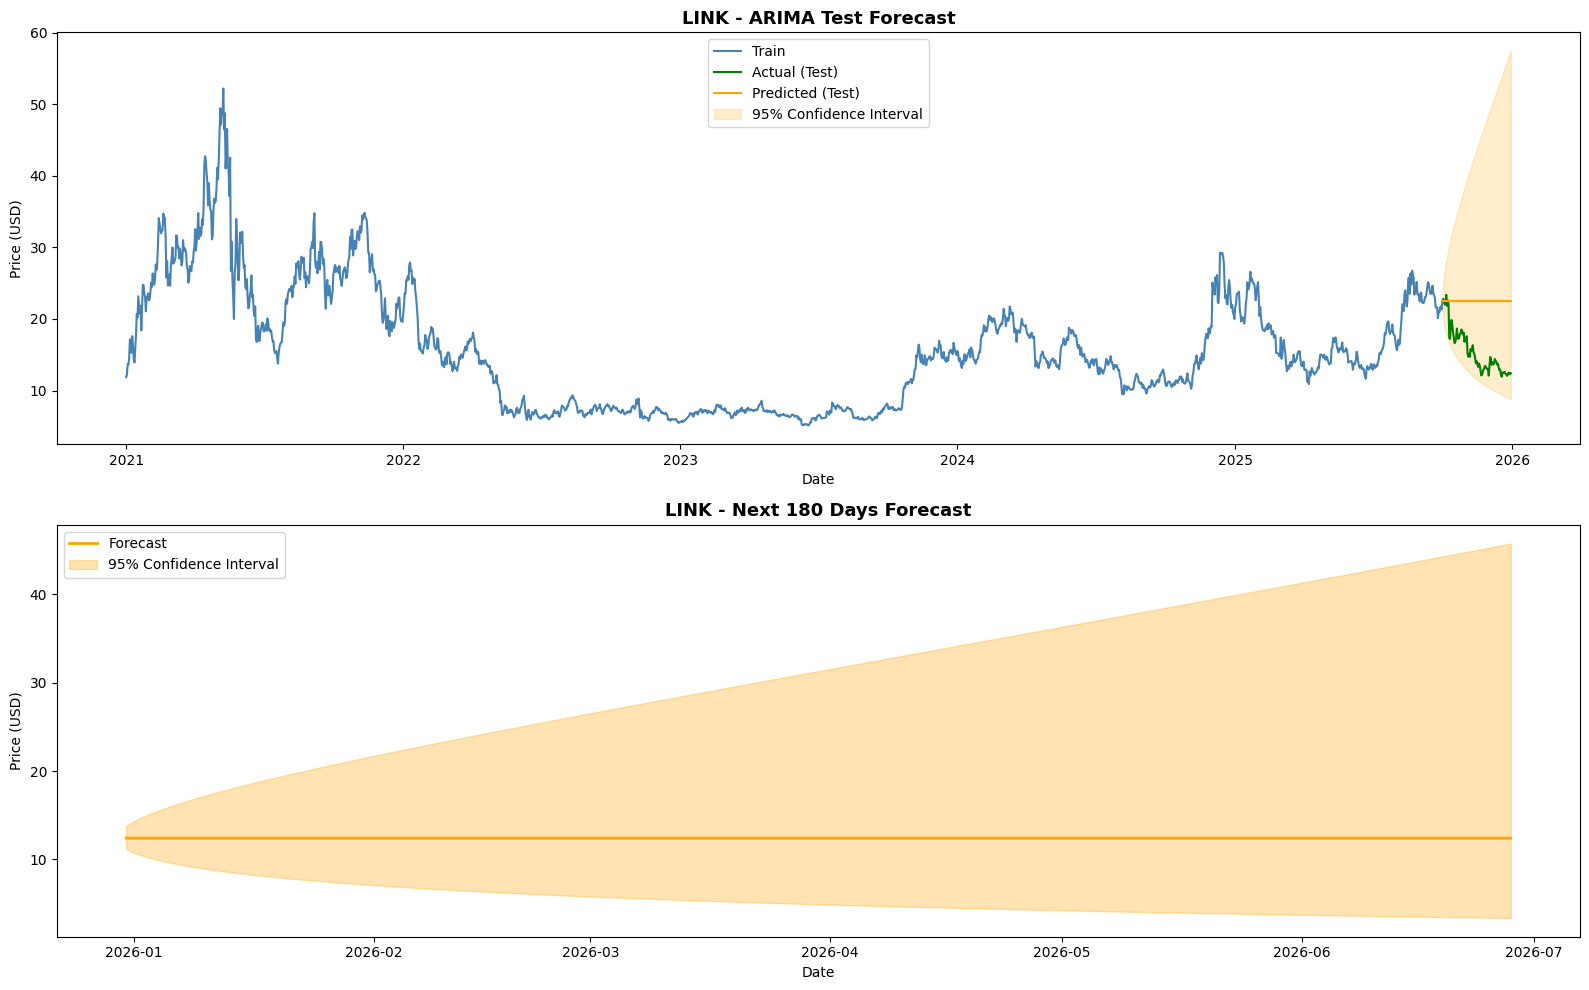

  Saved: LINK_forecast.png

Training ARIMA for: LTC
----------------------------------------
  Using order: (2, 1, 2)
  MAE: 24.0957  |  RMSE: 26.1636  |  MAPE: 28.2054%
  Saved: LTC_forecast.csv


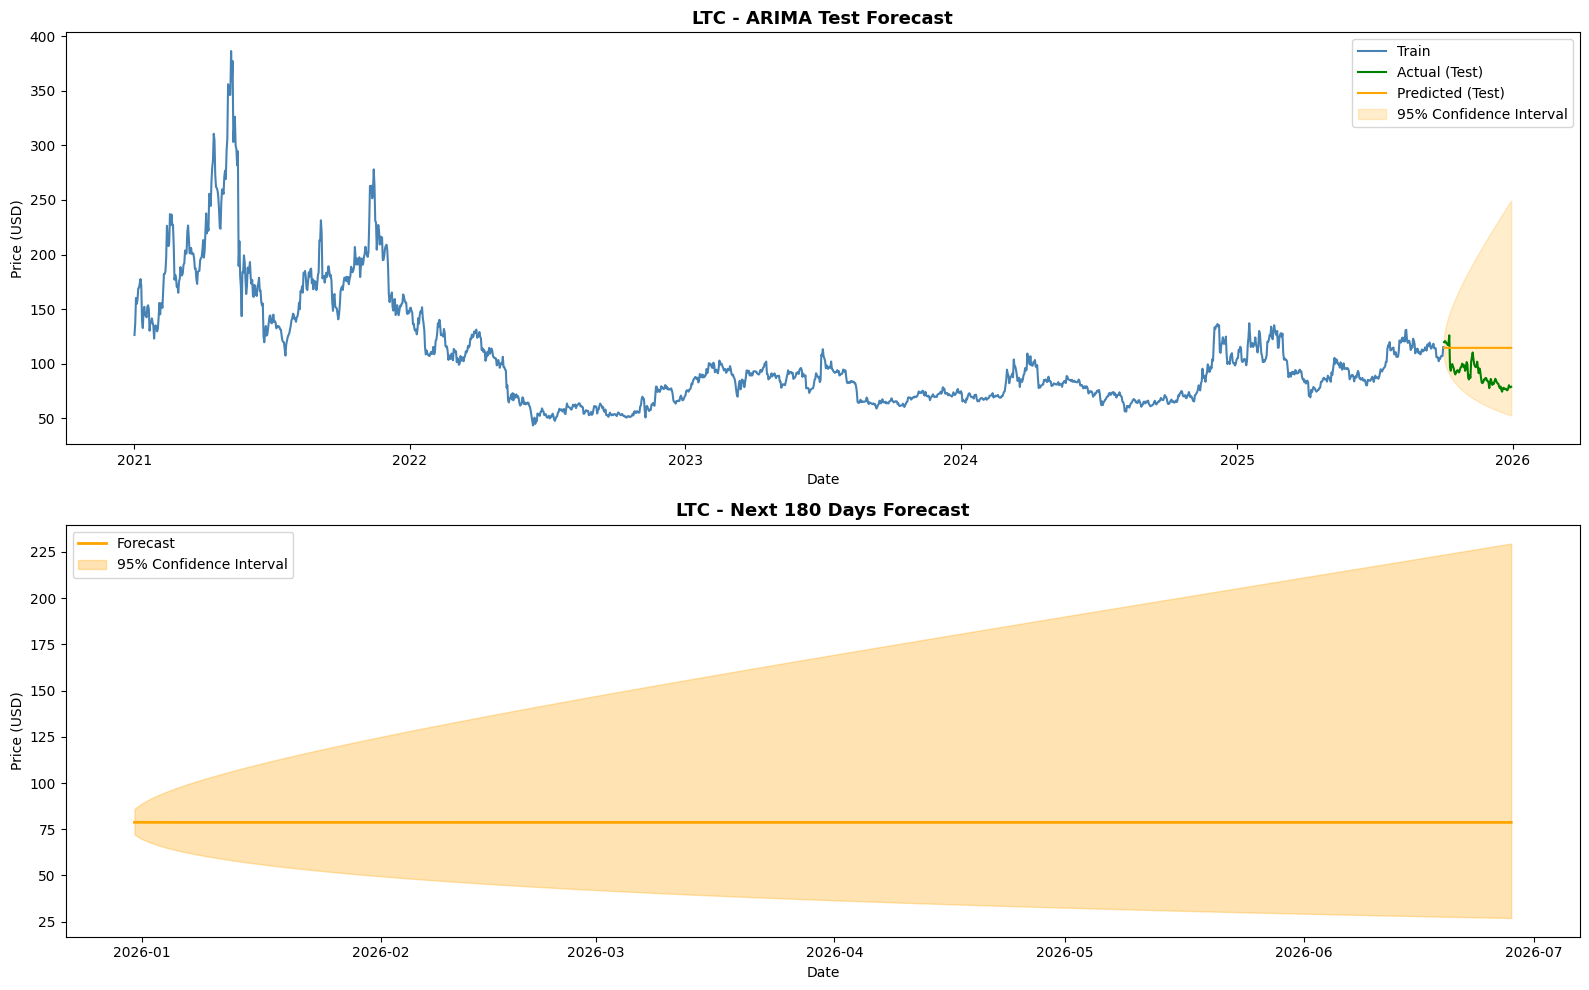

  Saved: LTC_forecast.png

Training ARIMA for: SOL
----------------------------------------
  Using order: (2, 1, 1)
  MAE: 63.7961  |  RMSE: 71.0384  |  MAPE: 45.5824%
  Saved: SOL_forecast.csv


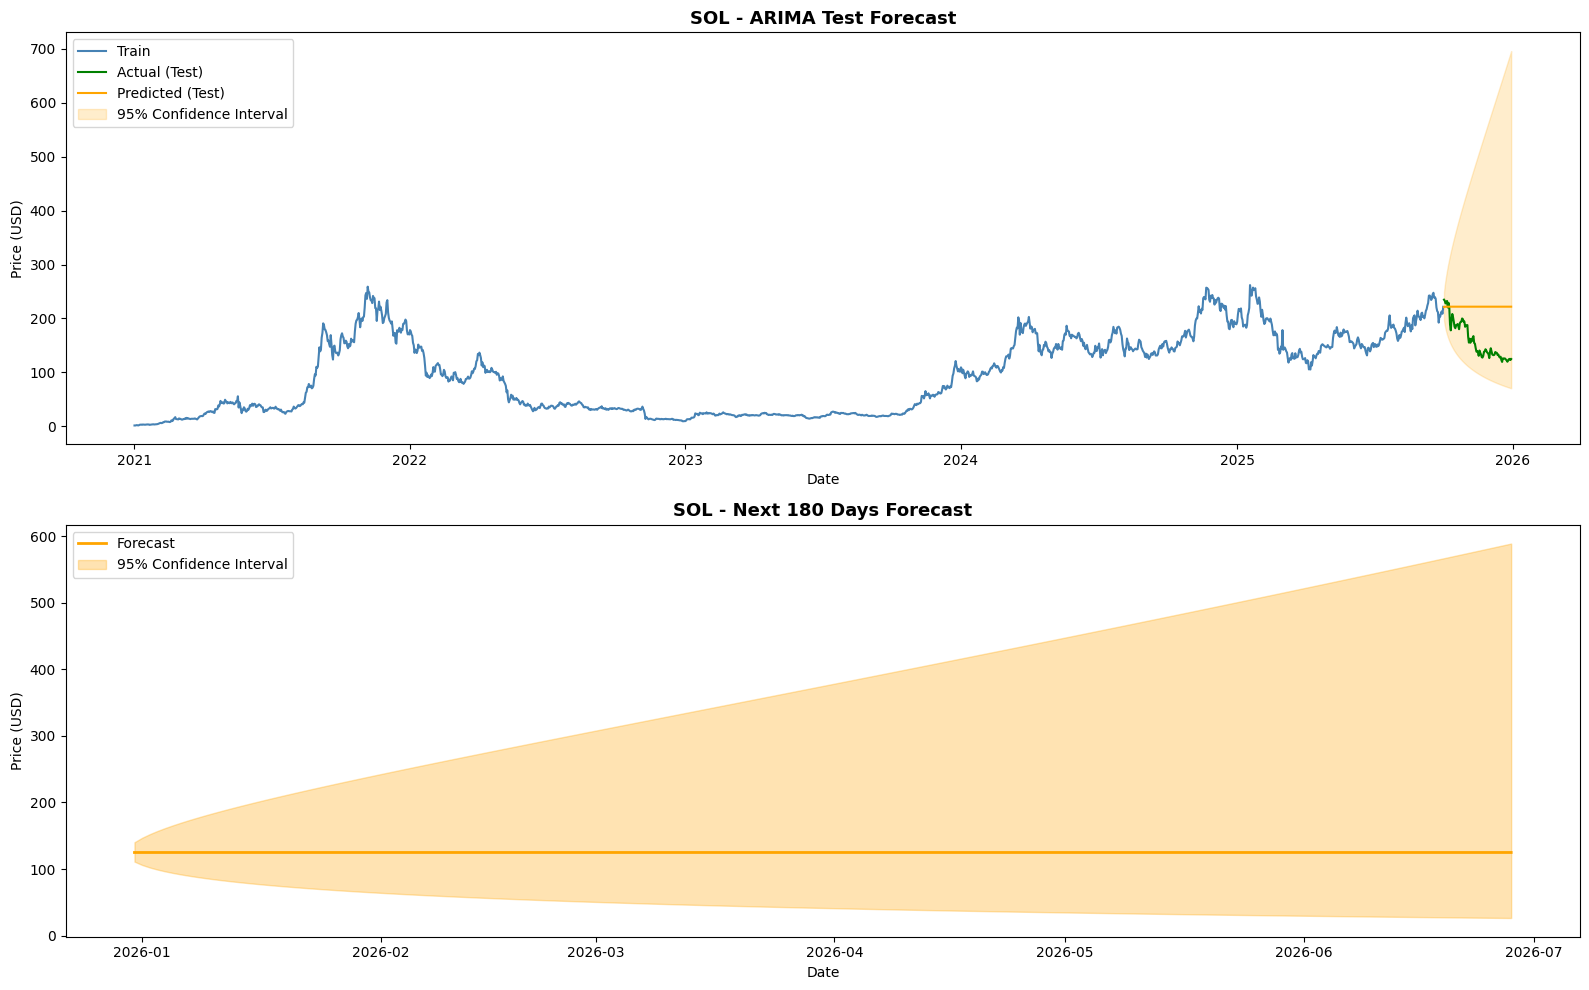

  Saved: SOL_forecast.png

Training ARIMA for: XRP
----------------------------------------
  Using order: (2, 1, 2)
  MAE: 0.6833  |  RMSE: 0.7441  |  MAPE: 32.377%


g:\My Drive\crypto project\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Saved: XRP_forecast.csv


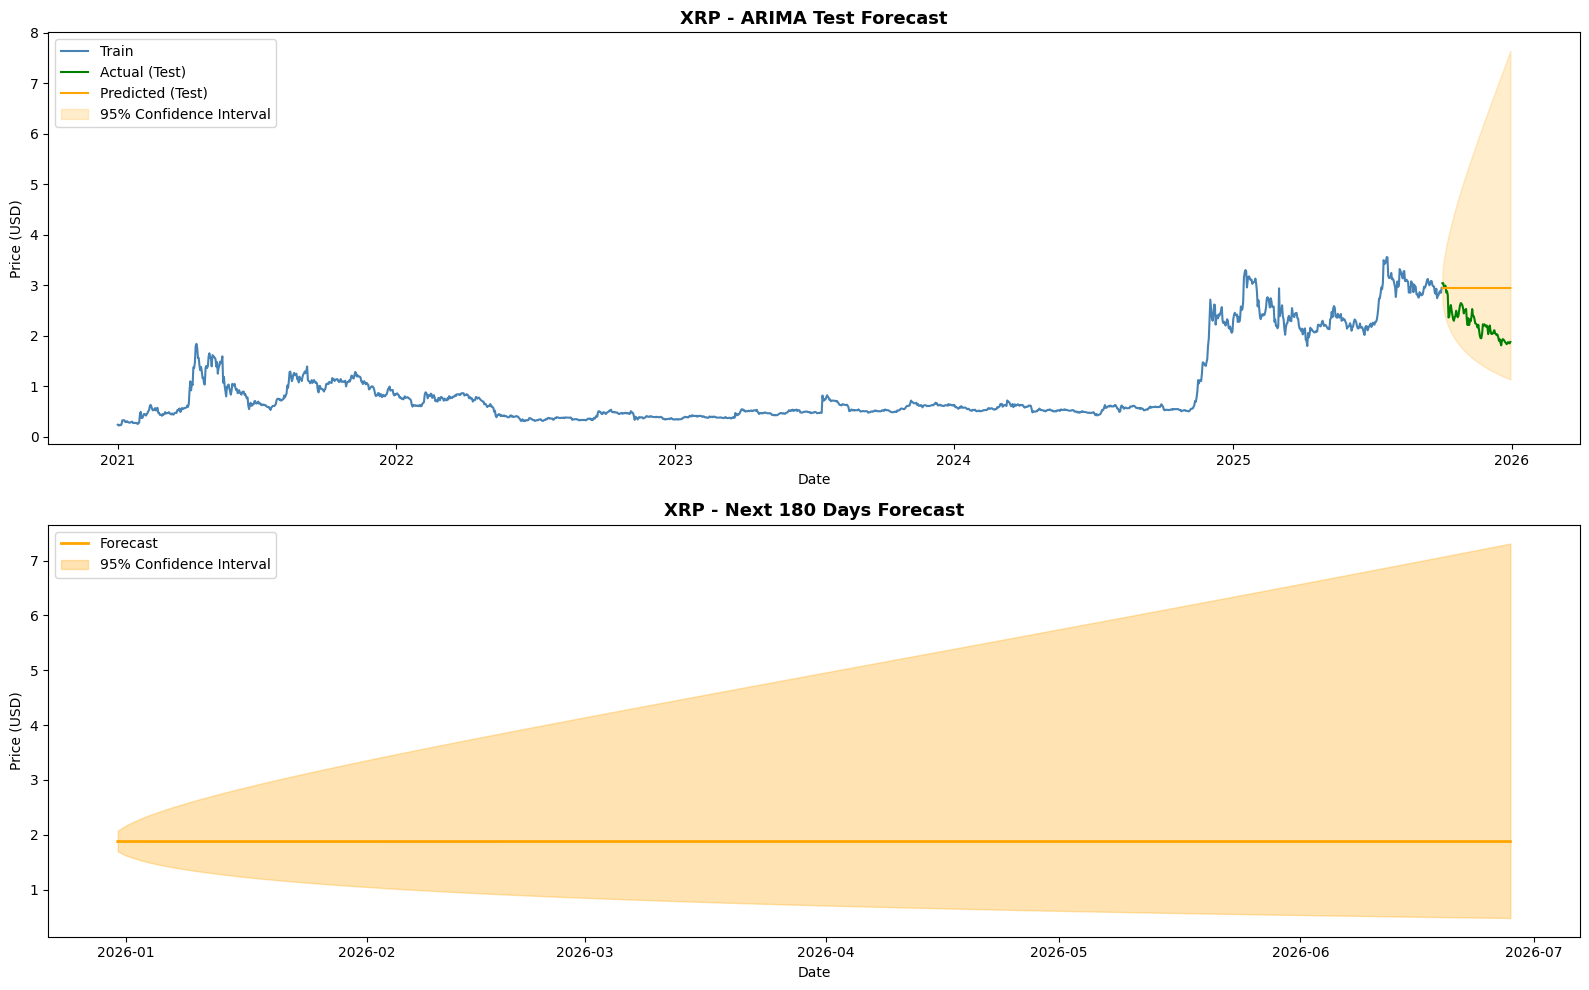

  Saved: XRP_forecast.png

All ARIMA models trained successfully.


In [ ]:
FORECAST_DAYS = 180
output_dir    = "../data/forecasts/arima"
all_metrics   = []
all_forecasts = []

for crypto in cryptos:
    print(f"\nTraining ARIMA for: {crypto}")
    print("-" * 40)

    crypto_df  = prepare_arima_data(df, crypto)
    log_series = crypto_df["Log_Close"].values

    # Train / test split
    train_size = len(log_series) - 90
    train      = log_series[:train_size]
    test       = log_series[train_size:]

    order = ARIMA_ORDERS.get(crypto, (1, 1, 1))
    print(f"  Using order: {order}")

    # Fit model on train
    model  = SARIMAX(train, order=order,
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    result = model.fit(disp=False)

    # Forecast test period only (90 days)
    test_forecast_obj  = result.get_forecast(steps=90)
    test_forecast_mean = test_forecast_obj.predicted_mean
    test_conf_int      = np.array(test_forecast_obj.conf_int(alpha=0.05))

    # Evaluate on test period (original price scale)
    test_pred   = np.exp(test_forecast_mean)
    test_actual = np.exp(test)
    metrics     = evaluate_model(test_actual, test_pred)
    metrics["Crypto"] = crypto
    metrics["Order"]  = str(order)
    all_metrics.append(metrics)
    print(f"  MAE: {metrics['MAE']}  |  RMSE: {metrics['RMSE']}  |  MAPE: {metrics['MAPE']}%")

    # Retrain on full data for final forecast
    full_model  = SARIMAX(log_series, order=order,
                         enforce_stationarity=False,
                         enforce_invertibility=False)
    full_result = full_model.fit(disp=False)

    # Forecast future 180 days
    full_forecast      = full_result.get_forecast(steps=FORECAST_DAYS)
    full_forecast_mean = full_forecast.predicted_mean
    full_conf_int      = np.array(full_forecast.conf_int(alpha=0.05))

    # Save forecast CSV
    future_dates = pd.date_range(
        crypto_df["Date"].max() + pd.Timedelta(days=1), periods=FORECAST_DAYS
    )
    forecast_out = pd.DataFrame({
        "Date"       : future_dates,
        "Forecast"   : np.exp(full_forecast_mean),
        "Lower_Bound": np.exp(full_conf_int[:, 0]),
        "Upper_Bound": np.exp(full_conf_int[:, 1]),
        "Crypto"     : crypto
    })
    forecast_out.to_csv(f"{output_dir}/{crypto}_forecast.csv", index=False)
    print(f"  Saved: {crypto}_forecast.csv")
    all_forecasts.append(forecast_out)

    # Plot forecast
    train_dates  = crypto_df["Date"][:train_size]
    test_dates   = crypto_df["Date"][train_size:]
    train_prices = crypto_df["Close"][:train_size]
    test_prices  = crypto_df["Close"][train_size:]

    fig, axes = plt.subplots(2, 1, figsize=(16, 10))

    # Plot 1: Train + Test actual vs predicted
    axes[0].plot(train_dates, train_prices, label="Train", color="steelblue", linewidth=1.5)
    axes[0].plot(test_dates, test_prices, label="Actual (Test)", color="green", linewidth=1.5)
    axes[0].plot(test_dates, np.exp(test_forecast_mean), label="Predicted (Test)", color="orange", linewidth=1.5)
    axes[0].fill_between(test_dates,
                         np.exp(test_conf_int[:, 0]),
                         np.exp(test_conf_int[:, 1]),
                         alpha=0.2, color="orange", label="95% Confidence Interval")
    axes[0].set_title(f"{crypto} - ARIMA Test Forecast", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel("Price (USD)")
    axes[0].legend()

    # Plot 2: Future 180 days only
    axes[1].plot(future_dates, np.exp(full_forecast_mean), color="orange", linewidth=2, label="Forecast")
    axes[1].fill_between(future_dates,
                         np.exp(full_conf_int[:, 0]),
                         np.exp(full_conf_int[:, 1]),
                         alpha=0.3, color="orange", label="95% Confidence Interval")
    axes[1].set_title(f"{crypto} - Next 180 Days Forecast", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel("Price (USD)")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f"{output_dir}/{crypto}_forecast.png", dpi=150)
    plt.show()
    plt.close()
    print(f"  Saved: {crypto}_forecast.png")

print("\nAll ARIMA models trained successfully.")

## Save Combined Forecast
Concatenate all 10 cryptocurrency forecasts into a single CSV file
for use in the Power BI dashboard and model comparison notebook.

In [ ]:
combined_forecast = pd.concat(all_forecasts, ignore_index=True)
combined_forecast.to_csv(f"{output_dir}/combined_forecast.csv", index=False)
print("Saved: combined_forecast.csv")
print("Shape:", combined_forecast.shape)
combined_forecast.head()

Saved: combined_forecast.csv
Shape: (1800, 5)


,Date,Forecast,Lower_Bound,Upper_Bound,Crypto
0,2025-12-31,0.351011,0.317989,0.387463,ADA
1,2026-01-01,0.351051,0.306150,0.402537,ADA
2,2026-01-02,0.351036,0.296957,0.414964,ADA
3,2026-01-03,0.351042,0.289509,0.425653,ADA
4,2026-01-04,0.351040,0.283057,0.435349,ADA


## Model Performance Summary
Compile and display ARIMA performance metrics for all 10 cryptocurrencies
including the ARIMA order used, sorted by MAPE (best to worst).

In [ ]:
metrics_df = pd.DataFrame(all_metrics)[["Crypto", "Order", "MAE", "RMSE", "MAPE"]]
metrics_df = metrics_df.sort_values("MAPE")

print("ARIMA Model Performance Summary:")
print(metrics_df.to_string(index=False))

metrics_df.to_csv(f"{output_dir}/model_metrics.csv", index=False)
print("\nSaved: model_metrics.csv")

ARIMA Model Performance Summary:
Crypto     Order        MAE       RMSE    MAPE
   BNB (1, 1, 1)   129.7031   141.9470 13.5137
   BTC (2, 1, 2) 19685.8460 22420.1843 21.2479
   LTC (2, 1, 2)    24.0957    26.1636 28.2054
   ETH (2, 1, 2)   939.8281  1056.1825 29.9646
   XRP (2, 1, 2)     0.6833     0.7441 32.3770
   SOL (2, 1, 1)    63.7961    71.0384 45.5824
  LINK (1, 1, 1)     7.0929     7.6858 50.9037
  DOGE (1, 1, 1)     0.0811     0.0880 54.1987
   DOT (1, 1, 1)     1.4652     1.5996 64.5874
   ADA (1, 1, 1)     0.3194     0.3500 71.7328

Saved: model_metrics.csv


## Performance Comparison Plot
Visualize MAE, RMSE, and MAPE for all cryptocurrencies side by side.
Sorted in ascending order so best-performing coins appear at the top.

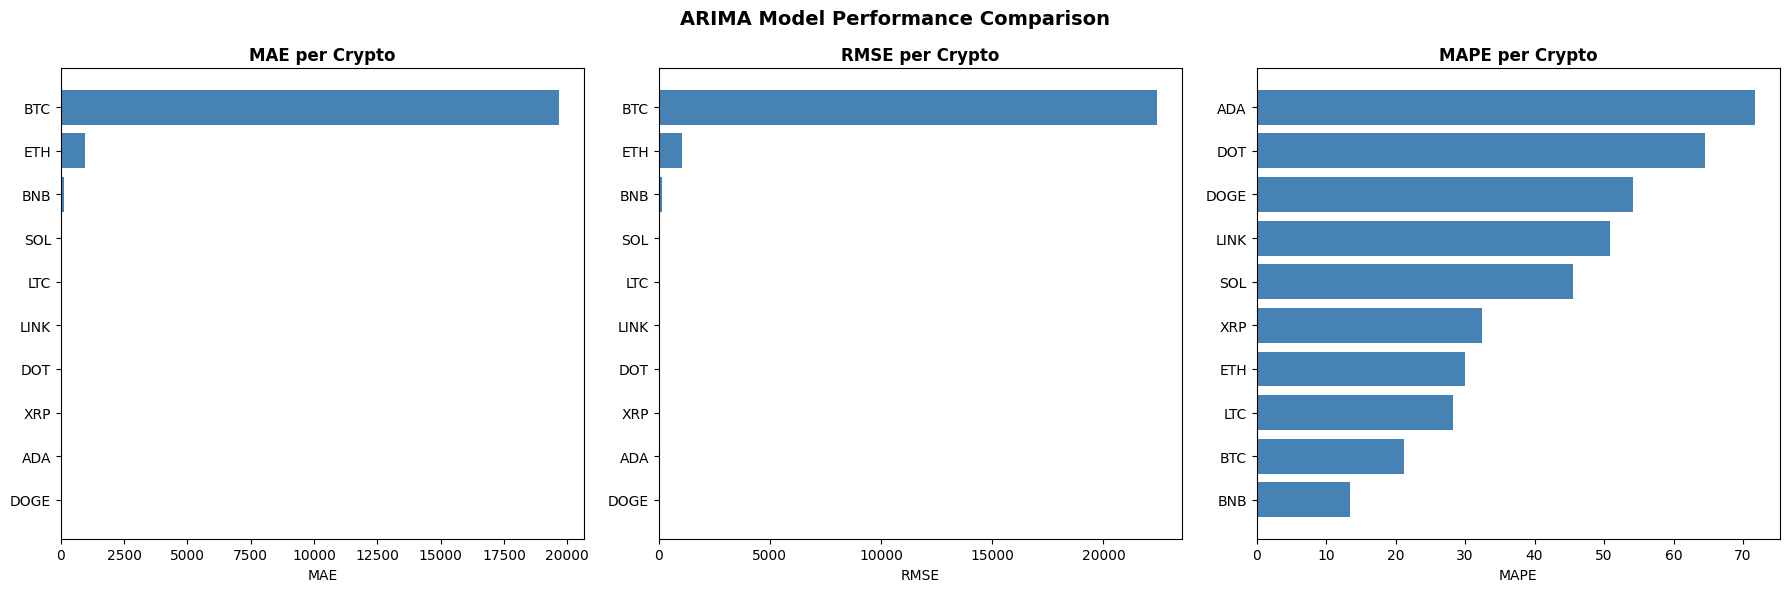

Saved: model_performance_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, metric in zip(axes, ["MAE", "RMSE", "MAPE"]):
    sorted_df = metrics_df.sort_values(metric)
    ax.barh(sorted_df["Crypto"], sorted_df[metric], color="steelblue")
    ax.set_title(f"{metric} per Crypto", fontweight="bold")
    ax.set_xlabel(metric)

plt.suptitle("ARIMA Model Performance Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{output_dir}/model_performance_comparison.png", dpi=150)
plt.show()
print("Saved: model_performance_comparison.png")

## Summary

| Output | Description | Location |
|--------|-------------|----------|
| BTC_acf_pacf.png | ACF & PACF analysis chart | data/forecasts/arima/ |
| {CRYPTO}_forecast.csv | 180-day forecast per coin | data/forecasts/arima/ |
| {CRYPTO}_forecast.png | Forecast chart per coin | data/forecasts/arima/ |
| combined_forecast.csv | All 10 cryptos combined | data/forecasts/arima/ |
| model_metrics.csv | MAE, RMSE, MAPE, Order | data/forecasts/arima/ |
| model_performance_comparison.png | Performance bar charts | data/forecasts/arima/ |

**Key Findings:**
- ARIMA significantly outperforms Prophet across all 10 cryptocurrencies
- BNB achieves best performance (MAPE ~13.5%) using order (1,1,1)
- Log transformation is critical — linearizes exponential crypto growth
- Average MAPE across all coins: ~41.2%
- ARIMA confidence intervals widen rapidly over time due to uncertainty
  compounding with each forecast step

**Next Step:** `07_lstm_forecasting.ipynb`